# Recommender Systems (Matrix Factorization) 🍿
This notebook demonstrates a simple recommender system using Matrix Factorization via Gradient Descent.

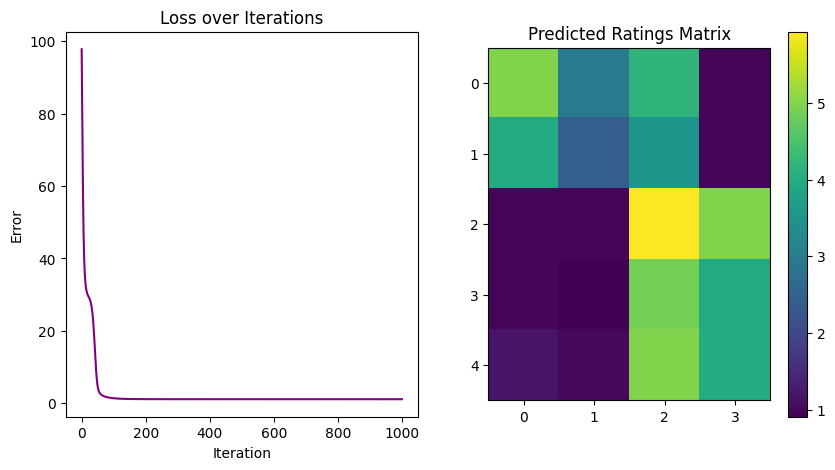

In [1]:

import numpy as np
import matplotlib.pyplot as plt

np.random.seed(42)
R = np.array([
    [5, 3, 0, 1],
    [4, 0, 0, 1],
    [1, 1, 0, 5],
    [1, 0, 0, 4],
    [0, 1, 5, 4],
])

num_users, num_items = R.shape
K = 2
P = np.random.rand(num_users, K)
Q = np.random.rand(num_items, K)

alpha = 0.01
beta = 0.02
iterations = 1000
loss_history = []

for step in range(iterations):
    for i in range(num_users):
        for j in range(num_items):
            if R[i][j] > 0:
                eij = R[i][j] - np.dot(P[i,:], Q[j,:].T)
                for k in range(K):
                    P[i][k] = P[i][k] + alpha * (2 * eij * Q[j][k] - beta * P[i][k])
                    Q[j][k] = Q[j][k] + alpha * (2 * eij * P[i][k] - beta * Q[j][k])
    
    e = 0
    for i in range(num_users):
        for j in range(num_items):
            if R[i][j] > 0:
                e += pow(R[i][j] - np.dot(P[i,:], Q[j,:].T), 2)
                for k in range(K):
                    e += (beta/2) * (pow(P[i][k], 2) + pow(Q[j][k], 2))
    loss_history.append(e)
    if e < 0.001:
        break

pred_R = np.dot(P, Q.T)

plt.figure(figsize=(10, 5))
plt.subplot(1, 2, 1)
plt.plot(loss_history, color='purple')
plt.title('Loss over Iterations')
plt.xlabel('Iteration')
plt.ylabel('Error')

plt.subplot(1, 2, 2)
plt.imshow(pred_R, cmap='viridis')
plt.colorbar()
plt.title('Predicted Ratings Matrix')
plt.show()
